In [1349]:
import networkx as nx
import random
from dataclasses import dataclass
from typing import Dict, Optional, List
import numpy as np
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout
from tribal import BaseTree
from tribal.expansion_graph import ConstructGraph, ConstructGraphMulti
from tribal.lineage_tree import MPTR as MPTR_original
# from tribal.draw_tree import plot_tree
from tribal.mptr_dag import MPTR_DAG
from tribal.mptr_cp import MPTR_CP
from tribal.mptr_cp_gur import MPTR_CP_GUR
from itertools import combinations
import pyomo.environ as pyo

In [1350]:
def random_binary_tree(n_leaves: int, seed: Optional[int] = None) -> nx.Graph:
    if n_leaves < 2:
        raise ValueError("Need at least 2 leaves for a binary tree.")

    rng = random.Random(seed)

    T = nx.Graph()
    T.add_edge(0, 1)
    next_node = 2

    for _ in range(n_leaves - 2):
        u, v = rng.choice(list(T.edges()))

        w = next_node
        next_node += 1

        T.remove_edge(u, v)
        T.add_edge(u, w)
        T.add_edge(w, v)

        x = next_node
        next_node += 1
        T.add_edge(w, x)

    return T

def random_rooted_binary_tree(
    n_leaves: int,
    seed: Optional[int] = None
) -> tuple[nx.DiGraph, int]:
    rng = random.Random(seed)

    T = random_binary_tree(n_leaves, seed=seed)

    u, v = rng.choice(list(T.edges()))

    r = max(T.nodes()) + 1 
    T.remove_edge(u, v)
    T.add_edge(u, r)
    T.add_edge(r, v)

    Di = nx.DiGraph()
    Di.add_nodes_from(T.nodes())
    Di.add_edges_from(nx.bfs_edges(T, source=r))

    return Di, r

@dataclass
class DiscreteCharacter:
    name: str
    n_states: int
    P: np.ndarray
    preserve_triangle: bool = False

    def sample_next_state(
        self,
        current_state: int,
        rng: Optional[np.random.Generator] = None
    ) -> int:
        if rng is None:
            rng = np.random.default_rng()
        probs = self.P[current_state]
        return int(rng.choice(self.n_states, p=probs))
    
def threshold_and_renormalize(probs: np.ndarray, threshold: float = 1e-8) -> np.ndarray:
    cleaned_probs = np.where(probs < threshold, 0.0, probs)
    total = np.sum(cleaned_probs)
    
    if total > 0:
        return cleaned_probs / total
    else:
        fallback = np.zeros_like(probs)
        fallback[np.argmax(probs)] = 1.0
        return fallback

# def random_transition_matrix(n_states: int, alpha: float = 1.0) -> np.ndarray:
#     alphas = np.full(n_states, alpha, dtype=float)
#     rows = [threshold_and_renormalize(np.random.dirichlet(alphas)) for _ in range(n_states)]
#     return np.vstack(rows)

def random_transition_matrix(
    n_states: int, 
    alpha: float = 1.0,
    preserve_triangle: bool = False,
    max_iters: int = 10000
) -> np.ndarray:
    alphas = np.full(n_states, alpha, dtype=float)
    
    if not preserve_triangle:
        rows = [threshold_and_renormalize(np.random.dirichlet(alphas)) for _ in range(n_states)]
        return np.vstack(rows)
        
    for _ in range(max_iters):
        P = np.vstack([threshold_and_renormalize(np.random.dirichlet(alphas)) for _ in range(n_states)])
        
        all_valid = True
        for i in range(n_states):
            for j in range(n_states):
                if i == j: continue
                for k in range(n_states):
                    if k == i or k == j: continue
                    if P[i, k] < P[i, j] * P[j, k]:
                        all_valid = False
                        break
                if not all_valid: break
            if not all_valid: break
            
        if all_valid:
            return P
            
    print("Reached max iterations for fully connected transition matrix")
    return P


# def random_irreversible_transition_matrix(
#     n_states: int,
#     alpha: float = 1.0,
#     self_bias: float = 1.0
# ) -> np.ndarray:
#     P = np.zeros((n_states, n_states), dtype=float)
#     for i in range(n_states):
#         k = n_states - i
#         alphas = np.full(k, alpha, dtype=float)
#         alphas[0] *= self_bias
#         probs = threshold_and_renormalize(np.random.dirichlet(alphas))
#         P[i, i:] = probs
#     return P

def random_irreversible_transition_matrix(
    n_states: int,
    alpha: float = 1.0,
    self_bias: float = 1.0,
    preserve_triangle: bool = False,
    max_iters: int = 10000
) -> np.ndarray:
    P = np.zeros((n_states, n_states), dtype=float)
    
    # Process bottom-up (reverse order) so descendants are available for checking
    for i in range(n_states - 1, -1, -1):
        k_len = n_states - i
        alphas = np.full(k_len, alpha, dtype=float)
        alphas[0] *= self_bias
        
        if not preserve_triangle:
            probs = threshold_and_renormalize(np.random.dirichlet(alphas))
            P[i, i:] = probs
        else:
            accepted = False
            for _ in range(max_iters):
                probs = threshold_and_renormalize(np.random.dirichlet(alphas))
                
                all_valid = True
                for j_idx in range(1, k_len):
                    j = i + j_idx
                    p_i_j = probs[j_idx]
                    
                    for k_idx in range(j_idx + 1, k_len):
                        k = i + k_idx
                        p_i_k = probs[k_idx]
                        
                        if p_i_k < p_i_j * P[j, k]:
                            all_valid = False
                            break
                    if not all_valid:
                        break
                        
                if all_valid:
                    P[i, i:] = probs
                    accepted = True
                    break
                    
            if not accepted:
                print(f"Reached max iterations for irreversible matrix state {i}")
                P[i, i:] = probs
                
    return P

# def make_reversible_character(
#     name: str,
#     n_states: int,
#     alpha: float = 1.0
# ) -> DiscreteCharacter:
#     P = random_transition_matrix(n_states, alpha=alpha)
#     return DiscreteCharacter(name=name, n_states=n_states, P=P)


# def make_irreversible_character(
#     name: str,
#     n_states: int,
#     alpha: float = 1.0,
#     self_bias: float = 1.0
# ) -> DiscreteCharacter:
#     P = random_irreversible_transition_matrix(
#         n_states=n_states, alpha=alpha, self_bias=self_bias
#     )
#     return DiscreteCharacter(name=name, n_states=n_states, P=P)

def make_reversible_character(
    name: str,
    n_states: int,
    alpha: float = 1.0,
    preserve_triangle: bool = False,
    max_iters: int = 10000
) -> DiscreteCharacter:
    P = random_transition_matrix(
        n_states, alpha=alpha, preserve_triangle=preserve_triangle, max_iters=max_iters
    )
    return DiscreteCharacter(name=name, n_states=n_states, P=P, preserve_triangle=preserve_triangle)


def make_irreversible_character(
    name: str,
    n_states: int,
    alpha: float = 1.0,
    self_bias: float = 1.0,
    preserve_triangle: bool = False,
    max_iters: int = 10000
) -> DiscreteCharacter:
    P = random_irreversible_transition_matrix(
        n_states=n_states, alpha=alpha, self_bias=self_bias, 
        preserve_triangle=preserve_triangle, max_iters=max_iters
    )
    return DiscreteCharacter(name=name, n_states=n_states, P=P, preserve_triangle=preserve_triangle)

def random_tree_transition_matrix_rejection(
    n_states: int,
    alpha: float = 1.0,
    self_bias: float = 1.0,
    root_state: int = 0,
    closure_prob: float = 0.0,
    preserve_triangle: bool = True,
    max_iters: int = 10000
) -> np.ndarray:
    if n_states < 1:
        print("Must have at least one states")
    if n_states == 1:
        return np.array([[1.0]])
        
    seq = list(np.random.randint(0, n_states, size=n_states - 2))
    undirected_tree = nx.from_prufer_sequence(seq)
    directed_edges = list(nx.bfs_edges(undirected_tree, source=root_state))
    
    T = nx.DiGraph()
    T.add_nodes_from(range(n_states))
    T.add_edges_from(directed_edges)
    
    P = np.zeros((n_states, n_states), dtype=float)
    
    nodes_bottom_up = list(reversed(list(nx.topological_sort(T))))
    
    for i in nodes_bottom_up:
        direct_children = list(T.successors(i))
        reachable = [i] + direct_children
        
        active_closures = []
        if closure_prob > 0:
            descendants = nx.descendants(T, i)
            closure_candidates = descendants - set(direct_children)
            for k in closure_candidates:
                if np.random.rand() < closure_prob:
                    reachable.append(k)
                    active_closures.append(k)
                    
        k_len = len(reachable)
        alphas = np.full(k_len, alpha, dtype=float)
        alphas[0] *= self_bias
        
        if not preserve_triangle or not active_closures:
            probs = threshold_and_renormalize(np.random.dirichlet(alphas))
            for idx, target_state in enumerate(reachable):
                P[i, target_state] = probs[idx]
        else:
            accepted = False
            for iter in range(max_iters):
                probs = threshold_and_renormalize(np.random.dirichlet(alphas))
                
                proposed_P = {target_state: probs[idx] for idx, target_state in enumerate(reachable)}
                
                all_valid = True
                for k in active_closures:
                    path = nx.shortest_path(T, source=i, target=k)
                    
                    prob_prod = 1.0
                    
                    prob_prod *= proposed_P[path[1]]
                    
                    for step in range(1, len(path) - 1):
                        u_step = path[step]
                        v_step = path[step+1]
                        prob_prod *= P[u_step, v_step]
                        
                    if proposed_P[k] < prob_prod:
                        all_valid = False
                        break
                        
                if all_valid:
                    for target_state, p_val in proposed_P.items():
                        P[i, target_state] = p_val
                    accepted = True
                    break
                    
            if not accepted:
                print("Reached max iterations")
                
    return P

# def random_dag_transition_matrix(
#     n_states: int,
#     edge_prob: float = 0.5,
#     alpha: float = 1.0,
#     self_bias: float = 1.0
# ) -> np.ndarray:
    
#     P = np.zeros((n_states, n_states), dtype=float)
    
#     if n_states == 1:
#         P[0, 0] = 1.0
#         return P

#     reachable = {i: [i] for i in range(n_states)}
    
#     for j in range(1, n_states):
#         i = np.random.randint(0, j)
#         reachable[i].append(j)
        
#     for i in range(n_states):
#         for j in range(i + 1, n_states):
#             if j not in reachable[i]:
#                 if np.random.rand() < edge_prob:
#                     reachable[i].append(j)
                    
#     for i in range(n_states):
#         reach = sorted(reachable[i]) 
        
#         k = len(reach)
#         alphas = np.full(k, alpha, dtype=float)
#         alphas[0] *= self_bias 
        
#         probs = threshold_and_renormalize(np.random.dirichlet(alphas))
        
#         for idx, target_state in enumerate(reach):
#             P[i, target_state] = probs[idx]
            
#     return P

def random_dag_transition_matrix(
    n_states: int,
    edge_prob: float = 0.5,
    alpha: float = 1.0,
    self_bias: float = 1.0,
    preserve_triangle: bool = False,
    max_iters: int = 10000
) -> np.ndarray:
    P = np.zeros((n_states, n_states), dtype=float)
    
    if n_states == 1:
        P[0, 0] = 1.0
        return P

    reachable = {i: [i] for i in range(n_states)}
    for j in range(1, n_states):
        i = np.random.randint(0, j)
        reachable[i].append(j)
        
    for i in range(n_states):
        for j in range(i + 1, n_states):
            if j not in reachable[i]:
                if np.random.rand() < edge_prob:
                    reachable[i].append(j)
                    
    # Process bottom-up (reverse topological order)
    for i in range(n_states - 1, -1, -1):
        reach = sorted(reachable[i]) 
        k_len = len(reach)
        alphas = np.full(k_len, alpha, dtype=float)
        alphas[0] *= self_bias 
        
        if not preserve_triangle:
            probs = threshold_and_renormalize(np.random.dirichlet(alphas))
            for idx, target_state in enumerate(reach):
                P[i, target_state] = probs[idx]
        else:
            accepted = False
            for _ in range(max_iters):
                probs = threshold_and_renormalize(np.random.dirichlet(alphas))
                proposed_P = {target_state: probs[idx] for idx, target_state in enumerate(reach)}
                
                all_valid = True
                for j in reach:
                    if j == i: continue
                    # ensure transitioning through j doesn't override the direct path
                    for k in reachable[j]:
                        if k in proposed_P:
                            if proposed_P[k] < proposed_P[j] * P[j, k]:
                                all_valid = False
                                break
                    if not all_valid:
                        break
                        
                if all_valid:
                    for target_state, p_val in proposed_P.items():
                        P[i, target_state] = p_val
                    accepted = True
                    break
                    
            if not accepted:
                print(f"Reached max iterations for DAG matrix state {i}")
                for target_state, p_val in proposed_P.items():
                    P[i, target_state] = p_val
            
    return P

def make_dag_character(
    name: str,
    n_states: int,
    edge_prob: float = 0.5,
    alpha: float = 1.0,
    self_bias: float = 1.0,
    preserve_triangle: bool = False
) -> DiscreteCharacter:
    P = random_dag_transition_matrix(
        n_states=n_states, 
        edge_prob=edge_prob, 
        alpha=alpha, 
        self_bias=self_bias,
        preserve_triangle=preserve_triangle
    )
    return DiscreteCharacter(name=name, n_states=n_states, P=P, preserve_triangle=preserve_triangle)

def make_tree_character(
    name: str,
    n_states: int,
    alpha: float = 1.0,
    self_bias: float = 1.0,
    root_state: int = 0,
    closure_prob: float = 0.0,
    preserve_triangle: bool = True,
    max_iters: int = 10000
) -> DiscreteCharacter:
    P = random_tree_transition_matrix_rejection(
        n_states=n_states, 
        alpha=alpha, 
        self_bias=self_bias,
        root_state=root_state,
        closure_prob=closure_prob,
        preserve_triangle=preserve_triangle,
        max_iters=max_iters
    )
    return DiscreteCharacter(name=name, n_states=n_states, P=P)

def simulate_on_tree(
    tree: nx.DiGraph,
    root: int,
    characters: Dict[str, DiscreteCharacter],
    rng: Optional[np.random.Generator] = None
) -> Dict[int, Dict[str, int]]:

    if rng is None:
        rng = np.random.default_rng()

    states: Dict[int, Dict[str, int]] = {}

    root_state: Dict[str, int] = {}
    for name, char in characters.items():
        root_state[name] = 0
    states[root] = root_state

    for node in nx.topological_sort(tree):
        if node == root:
            continue

        parent = next(tree.predecessors(node))
        parent_state = states[parent]

        node_state: Dict[str, int] = {}
        for name, char in characters.items():
            parent_val = parent_state[name]
            node_state[name] = char.sample_next_state(parent_val, rng=rng)

        states[node] = node_state

    for node, st in states.items():
        for name, val in st.items():
            tree.nodes[node][name] = val

    return tree,states

In [1351]:
def visualize_transitions(character: DiscreteCharacter, threshold: float = 0.001):
    P = character.P
    n_states = character.n_states
    
    G = nx.DiGraph()
    
    for i in range(n_states):
        G.add_node(i)
        for j in range(n_states):
            if P[i, j] >= threshold:
                G.add_edge(i, j, weight=P[i, j])

    plt.figure(figsize=(8, 6))
    plt.title(f"State Transitions: {character.name}")

    pos = nx.circular_layout(G)

    edges = G.edges()
    
    nx.draw(G, pos, node_size=1000, alpha=1, node_color="lightgreen", with_labels=True, font_size=9)

    edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}" for u, v in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, label_pos=0.3)

    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [1352]:
rng = np.random.default_rng(123)

isotype = make_irreversible_character(
    name="isotype",
    n_states=6,
    alpha=1.0,
    self_bias=1.0,
    preserve_triangle=True
)

functional_state = make_reversible_character(
    name="functional_state",
    n_states=8,
    alpha=0.8,
    preserve_triangle=True
)

third_property = make_reversible_character(
    name="third_property",
    n_states=3,
    alpha=0.8,
)

# characters = {"isotype": isotype}
# characters = {"isotype": isotype, "functional_state": functional_state}
# characters = {"isotype": isotype, "functional_state": functional_state, "third_property": third_property}

Reached max iterations for fully connected transition matrix


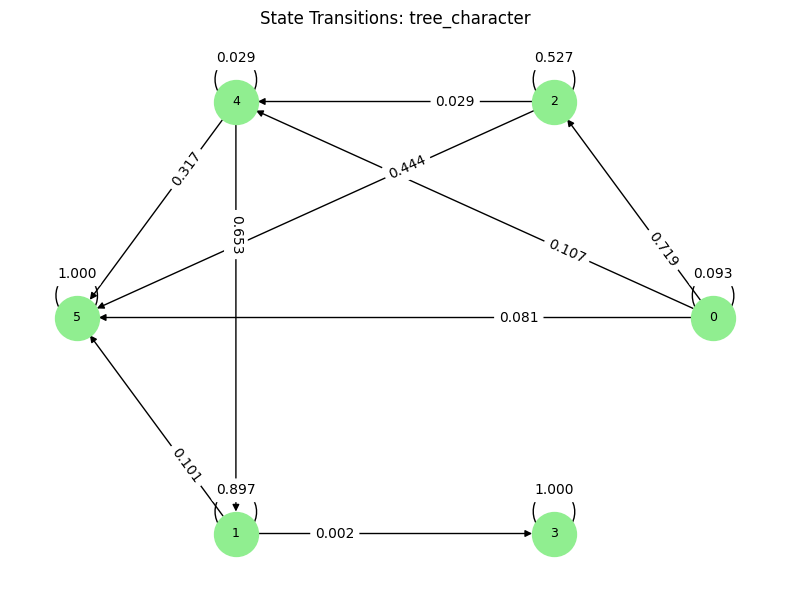

In [1353]:
tree_char = make_tree_character(name="tree_character", n_states=6, alpha=1,self_bias=1,closure_prob=0.5,preserve_triangle=True, max_iters=100)
visualize_transitions(tree_char)

In [1354]:
dag_char = make_dag_character(name="dag",n_states=10,edge_prob=0.1)
# visualize_transitions(dag_char)

In [1355]:
characters = {"isotype": isotype, "functional_state": functional_state, "tree_character": tree_char}
# characters = {"isotype": isotype, "functional_state": functional_state}

In [1356]:
n_leaves = 6
tree, root = random_rooted_binary_tree(n_leaves, seed=None)

tree,states = simulate_on_tree(tree, root, characters, rng=rng)

labels = {
    node: f"{node}_({','.join(str(v) for v in data.values())})"
    for node, data in states.items()
}

print(labels)

{10: '10_(0,0,0)', 8: '8_(3,0,2)', 9: '9_(0,1,4)', 2: '2_(5,3,5)', 6: '6_(5,5,2)', 1: '1_(5,2,5)', 4: '4_(5,7,5)', 3: '3_(5,4,2)', 7: '7_(5,3,5)', 0: '0_(5,0,5)', 5: '5_(5,6,5)'}


In [1357]:
def name_node(node, labels,  is_poly=False, is_leaf=False):
        lab = str(node)

        for l in labels:
            lab = lab + "_" + str(l)

        if is_poly:
             lab += "_p"
        return  lab

In [1358]:
def draw_tree(tree,i,labels=None):
    pos = graphviz_layout(tree,prog='dot',args=f"-Grankdir-TB")
    if labels==None:
        nx.draw(tree,pos,with_labels=True,node_size=500,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')
    else:
        nx.draw(tree,pos,with_labels=True,labels=labels,node_size=500,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')

In [1359]:
# def construct_graph(tree, states, characters,root):
#     # Loop for each character
#     # Leaves: Do nothing
#     # Inner Node: Add transitions that change state of the current character in the loop and whose probability is not 0 or INF.
#     # Keep the same parent and children IF transition probability is not 0 or INF.
#         # And only one character change? Should be able to follow an expanded path that is the same as multiple char changes.

#     # Might have to do some cleanup at the end for weird cases. No added node can end up as a leaf.
#         # Out/In degree >=1, also have at least one different parent than child (avoids reversible <-> like leaf)
#         # We also want to make sure each added node will eventually lead to one of the original leafs

#     # Need only one character change. For each inner node n, we want a cartesian product, then have all the "one step" *feasible* transitions,
#     # THEN connect parents and children (consider post traversal or something, surely we can get away with just adding one until the end (root?))
    
#     tree = tree.copy()
#     orig_nodes = list(tree.nodes()).copy()
#     node_extensions = []

#     for n in orig_nodes:
#         if tree.out_degree(n) != 0 and tree.in_degree(n) != 0:
#             new_states = states[root].copy()
#             new_node = name_node(n,new_states.values())
#             tree.add_node(new_node)
#             states[new_node] = new_states

#             for p in list(tree.predecessors(n)):
#                 tree.add_edge(p,new_node)

#             children = list(tree.successors(n))
#             for child in children:
#                 tree.add_edge(new_node,child)

#     for n in orig_nodes:
#         if tree.out_degree(n) != 0 and tree.in_degree(n) != 0:
#             tree.remove_node(n)

#     for c in characters:
#         P = characters[c].P # The probability matrix of character c
#         nodes = list(tree.nodes()).copy() # Only go through nodes before we expanded the character
#         for n in nodes:
#             if tree.out_degree(n) == 0 or tree.in_degree(n) == 0: # Tree is root or leaf, leave be.
#                 continue
#             else:
#                 current_states = states[n]

#                 states_to_add = [i for i,p in enumerate(P[0]) if i != 0]
                
#                 for s in states_to_add:
#                     new_states = current_states.copy()
#                     new_states[c] = s
#                     id = str(n).split('_')[0]
#                     new_node = name_node(id,new_states.values())

#                     states[new_node] = new_states
#                     tree.add_node(new_node)

#                     node_extensions.append(new_node)

#                     parents = list(tree.predecessors(n))

#                     for p in parents:
#                         parent_state = states[p][c]

#                         same_other_states = True
#                         for c2 in characters:
#                             if c2!=c:
#                                 if states[p][c] != new_states[c]:
#                                     same_other_states = False

#                         if(same_other_states and P[parent_state][s] != 0 and P[parent_state][s]!=np.Inf):
#                             tree.add_edge(p,new_node)
#                             if(p==new_node):
#                                 print("parent loop added")

#                     children = list(tree.successors(n))
#                     for child in children:
#                         child_state = states[child][c]

#                         same_other_states = True
#                         for c2 in characters:
#                             if c2!=c:
#                                 if states[child][c] != new_states[c]:
#                                     same_other_states = False

#                         if(same_other_states and P[s][child_state] != 0 and P[s][child_state]!=np.Inf):
#                             tree.add_edge(new_node,child)
#                             if(child==new_node):
#                                 print("child loop added")

#                 # For pairs of states to add, check if transition is there, add edge (name node)
#                 for s,t in combinations(states_to_add,2):
#                     states_s = current_states.copy()
#                     states_s[c] = s
#                     node_s = name_node(id,states_s.values())
#                     states_t = current_states.copy()
#                     states_t[c] = t
#                     node_t = name_node(id,states_t.values())

#                     if(node_t==node_s):
#                         print("s,t loop added")

#                     if(P[s][t] != 0 and P[s][t]!=np.Inf):
#                         tree.add_edge(node_s,node_t)
#                     if(P[t][s] != 0 and P[t][s]!=np.Inf):
#                         tree.add_edge(node_t,node_s)

#     cleaned = False

#     while not cleaned:
#         cleaned = True
#         for n in node_extensions:
#             if tree.out_degree(n) == 0:
#                 tree.remove_node(n)
#                 cleaned = False
#             if tree.out_degree(n) == 1 and tree.in_degree(n) == 1:
#                 parent = tree.predecessors(n)[0]
#                 child = tree.successors(n)[0]
#                 if parent == child:
#                     tree.remove_node(n)
#                     cleaned=False

#     return tree

# expansion_graph = construct_graph(tree,states,characters,root)

In [1360]:
def construct_expansion_graph(tree, states, characters, root_node):
    G = nx.DiGraph()
    char_list = list(characters.keys())
    char_states = {c: list(range(len(characters[c].P))) for c in char_list}
    
    root_state = tuple(states[root_node][c] for c in char_list)
    root_id = f"{root_node}_{root_state}"
    G.add_node(root_id, orig=root_node, state=root_state)
    
    expanded_map = {n: [] for n in tree.nodes()}
    expanded_map[root_node].append(root_id)

    for u in nx.topological_sort(tree):
        #u != root_node and
        if tree.out_degree(u) > 0:
            frontier = list(expanded_map[u])
            seen_in_u = set(frontier)
            
            while frontier:
                curr_u_exp = frontier.pop(0)
                curr_state = G.nodes[curr_u_exp]['state']
                
                for i, c in enumerate(char_list):
                    curr_val = curr_state[i]
                    for next_val in char_states[c]:
                        if next_val == curr_val: continue
                        prob = characters[c].P[curr_val][next_val]
                        
                        if prob > 0 and prob != np.inf:
                            new_state = list(curr_state)
                            new_state[i] = next_val
                            v_state = tuple(new_state)
                            v_exp = f"{u}_{v_state}"
                            
                            if v_exp not in seen_in_u:
                                G.add_node(v_exp, orig=u, state=v_state)
                                expanded_map[u].append(v_exp)
                                seen_in_u.add(v_exp)
                                frontier.append(v_exp)
                            
                            weight = -np.log(prob) if prob < 1.0 else 0.0
                            G.add_edge(curr_u_exp, v_exp, weight=weight)

        for v in tree.successors(u):
            is_leaf = (tree.out_degree(v) == 0)
            target_leaf_state = tuple(states[v][c] for c in char_list) if is_leaf else None

            for u_exp in expanded_map[u]:
                u_state = G.nodes[u_exp]['state']
                
                if not is_leaf or u_state == target_leaf_state:
                    v_id = f"{v}_{u_state}"
                    if v_id not in G:
                        G.add_node(v_id, orig=v, state=u_state)
                        expanded_map[v].append(v_id)
                    G.add_edge(u_exp, v_id, weight=0.0)

                for i, c in enumerate(char_list):
                    curr_val = u_state[i]
                    for next_val in char_states[c]:
                        if next_val == curr_val: continue
                        prob = characters[c].P[curr_val][next_val]
                        
                        if prob > 0 and prob != np.inf:
                            mutated_state = list(u_state)
                            mutated_state[i] = next_val
                            mutated_state = tuple(mutated_state)
                            
                            if is_leaf and mutated_state != target_leaf_state:
                                continue
                                
                            v_id = f"{v}_{mutated_state}"
                            if v_id not in G:
                                G.add_node(v_id, orig=v, state=mutated_state)
                                expanded_map[v].append(v_id)
                                
                            weight = -np.log(prob) if prob < 1.0 else 0.0
                            G.add_edge(u_exp, v_id, weight=weight)

    leaves_in_G = [n for n in G.nodes() if tree.out_degree(G.nodes[n]['orig']) == 0]
    reachable_to_leaf = set()
    for leaf in leaves_in_G:
        reachable_to_leaf.add(leaf)
        reachable_to_leaf.update(nx.ancestors(G, leaf))

    expansion_graph = G.subgraph(reachable_to_leaf).copy()

    return expansion_graph


In [1361]:
def only_contracted_chars_changed(u, v, states, chars_to_contract):
    
    first_node = next(iter(states))
    all_chars = list(states[first_node].keys())
    other_chars = [c for c in all_chars if c not in chars_to_contract]

    for c in other_chars:
        if states[u][c] != states[v][c]:
            return False
    
    return True

def contract_tree_by_characters(tree, states, characters, chars_to_contract):
    tree = tree.copy()
    contracted_states = states.copy()

    contracted_round = True

    while(contracted_round):
        contracted_round = False
        for u,v in tree.edges():
            if tree.out_degree(v)==0:
                continue
            if only_contracted_chars_changed(u, v, states, chars_to_contract):
                for n in tree.successors(v):
                    tree.add_edge(u,n)
                tree.remove_edge(u,v)
                tree.remove_node(v)
                contracted_states.pop(v)
                contracted_round=True
                break

    filtered_states = {
        node: {char: val for char, val in char_dict.items() if char in chars_to_contract}
        for node, char_dict in contracted_states.items()
    }

    contracted_characters = {
        char: obj for char, obj in characters.items() if char in chars_to_contract
    }
    
    return tree, filtered_states, contracted_characters

#Example call
contracted_tree, contracted_states, contracted_characters = contract_tree_by_characters(
    tree, 
    states, characters,
    chars_to_contract=["isotype","tree_character"])

# contracted_tree, contracted_states, contracted_characters = contract_tree_by_characters(
#     tree, 
#     states, characters,
#     chars_to_contract=["isotype"])

# contracted_tree, contracted_states = contract_tree_by_characters(
#     contracted_tree, 
#     contracted_states, 
#     char_to_contract="third_property")

contracted_labels = {
    node: f"{node}_({','.join(str(v) for v in data.values())})"
    for node, data in contracted_states.items()
}

expansion_graph = construct_expansion_graph(contracted_tree,contracted_states,contracted_characters,root)


In [1362]:
contracted_labels = {
    node: f"{node}_({','.join(str(v) for v in data.values())})"
    for node, data in contracted_states.items()
}

In [1363]:
contracted_characters

{'isotype': DiscreteCharacter(name='isotype', n_states=6, P=array([[0.27768736, 0.15731484, 0.02654055, 0.29646354, 0.09038585,
         0.15160785],
        [0.        , 0.15338494, 0.13312703, 0.29602896, 0.1514302 ,
         0.26602886],
        [0.        , 0.        , 0.21335263, 0.39083328, 0.06128909,
         0.33452501],
        [0.        , 0.        , 0.        , 0.44573452, 0.12428161,
         0.42998387],
        [0.        , 0.        , 0.        , 0.        , 0.01409807,
         0.98590193],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         1.        ]]), preserve_triangle=True),
 'tree_character': DiscreteCharacter(name='tree_character', n_states=6, P=array([[0.09317209, 0.        , 0.71859423, 0.        , 0.10679234,
         0.08144134],
        [0.        , 0.89674097, 0.        , 0.00213689, 0.        ,
         0.10112214],
        [0.        , 0.        , 0.52681085, 0.        , 0.02886956,
         0.44431959],
        [0.        , 0

In [1364]:
expansion_graph = construct_expansion_graph(contracted_tree,contracted_states,contracted_characters,root)

In [1365]:
def draw_tree(tree,i,labels=None):
    pos = graphviz_layout(tree,prog='dot',args=f"-Grankdir-TB")
    if labels==None:
        nx.draw(tree,pos,with_labels=False,node_size=1000,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')
    else:
        nx.draw(tree,pos,with_labels=True,labels=labels,node_size=1000,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')

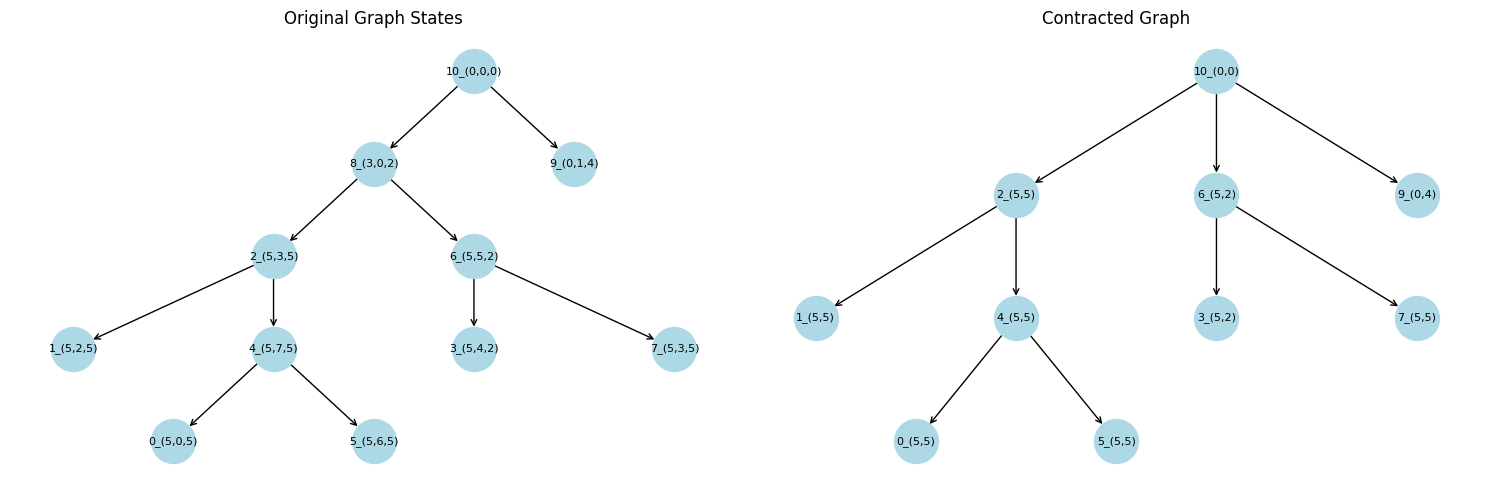

In [1366]:
fig,axes = plt.subplots(1, 2, figsize=(15,5))

draw_tree(tree,0, labels)
axes[0].set_title("Original Graph States")

draw_tree(contracted_tree,1,contracted_labels)
axes[1].set_title("Contracted Graph")

# draw_tree(expansion_graph,3)
# axes[3].set_title("Expansion Graph")

# draw_tree(contracted_tree,1)
# axes[1].set_title("Contracted Graph")

plt.tight_layout()
plt.show()

/var/folders/tj/bppvsjh16m990_1bbwvc05r80000gn/T/ipykernel_31699/3957182368.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


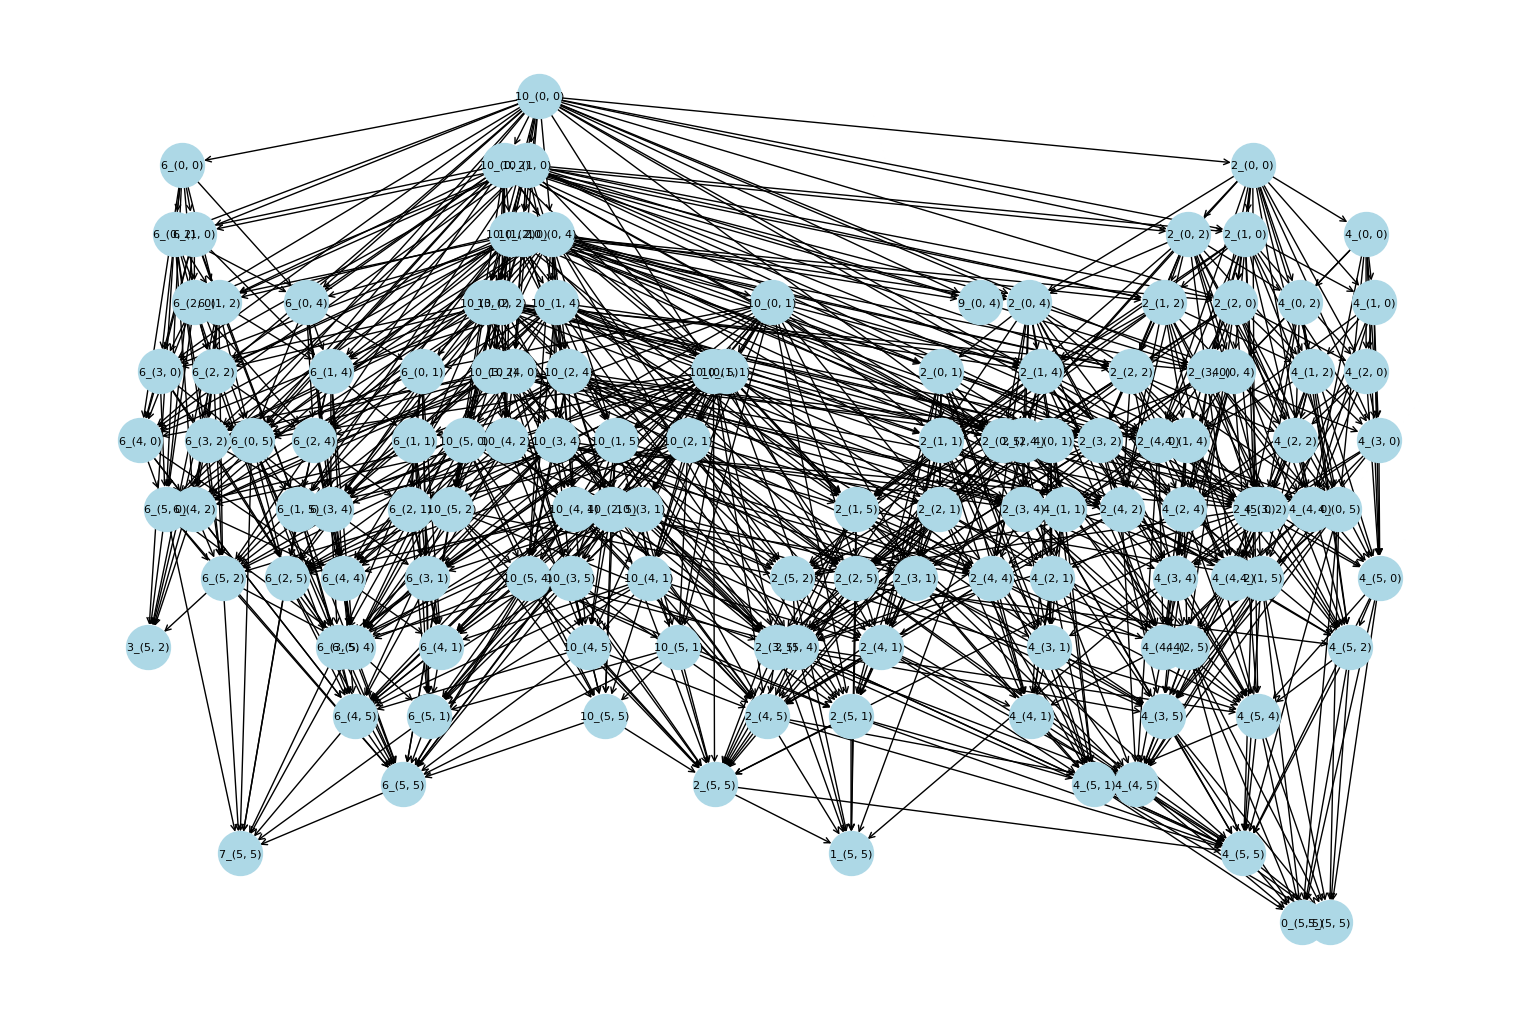

In [1382]:
plt.figure(figsize=(15,10))

pos = graphviz_layout(expansion_graph,prog='dot',args=f"-Grankdir-TB")
nx.draw(expansion_graph,pos,with_labels=True,node_size=1000,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,node_color='lightblue')

plt.tight_layout()
plt.show()

In [1368]:
base_tree = BaseTree(contracted_tree, root=root, id=0, name="contracted_test")

cg = ConstructGraphMulti(contracted_states, contracted_characters, root_identifier=root)
fg = cg.build(base_tree)

In [1369]:
mptr = MPTR_original(
    fg.G,
    base_tree.T,
    fg.find_terminals(),
    fg.iso_weights,
    fg.tree_to_graph,
    root=root,
)
score_m, tree_m = mptr.run()
print(f"MPTR objective = {score_m:.4f}")

MPTR objective = 6.0762


In [1370]:
# mptr_cp_g = MPTR_CP_GUR(
#     fg.G,
#     base_tree.T,
#     fg.find_terminals(),
#     fg.iso_weights,
#     fg.tree_to_graph,
#     root=root,
# )
# score_cp, tree_cp = mptr_cp_g.run()
# print(f"MPTR objective = {score_cp:.4f}")

In [1371]:
# mptr_cp = MPTR_CP(
#     fg.G,
#     base_tree.T,
#     fg.find_terminals(),
#     fg.iso_weights,
#     fg.tree_to_graph,
#     root=root,
# )
# score_cp, tree_cp = mptr_cp.run()
# print(f"MPTR objective = {score_m:.4f}")

In [1372]:
# m_reloaded = pyo.ConcreteModel()

# solver = pyo.SolverFactory('glpk')
# results = solver.solve("mptr_fully_constrained.lp", tee=True)

/var/folders/tj/bppvsjh16m990_1bbwvc05r80000gn/T/ipykernel_31699/3075795450.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


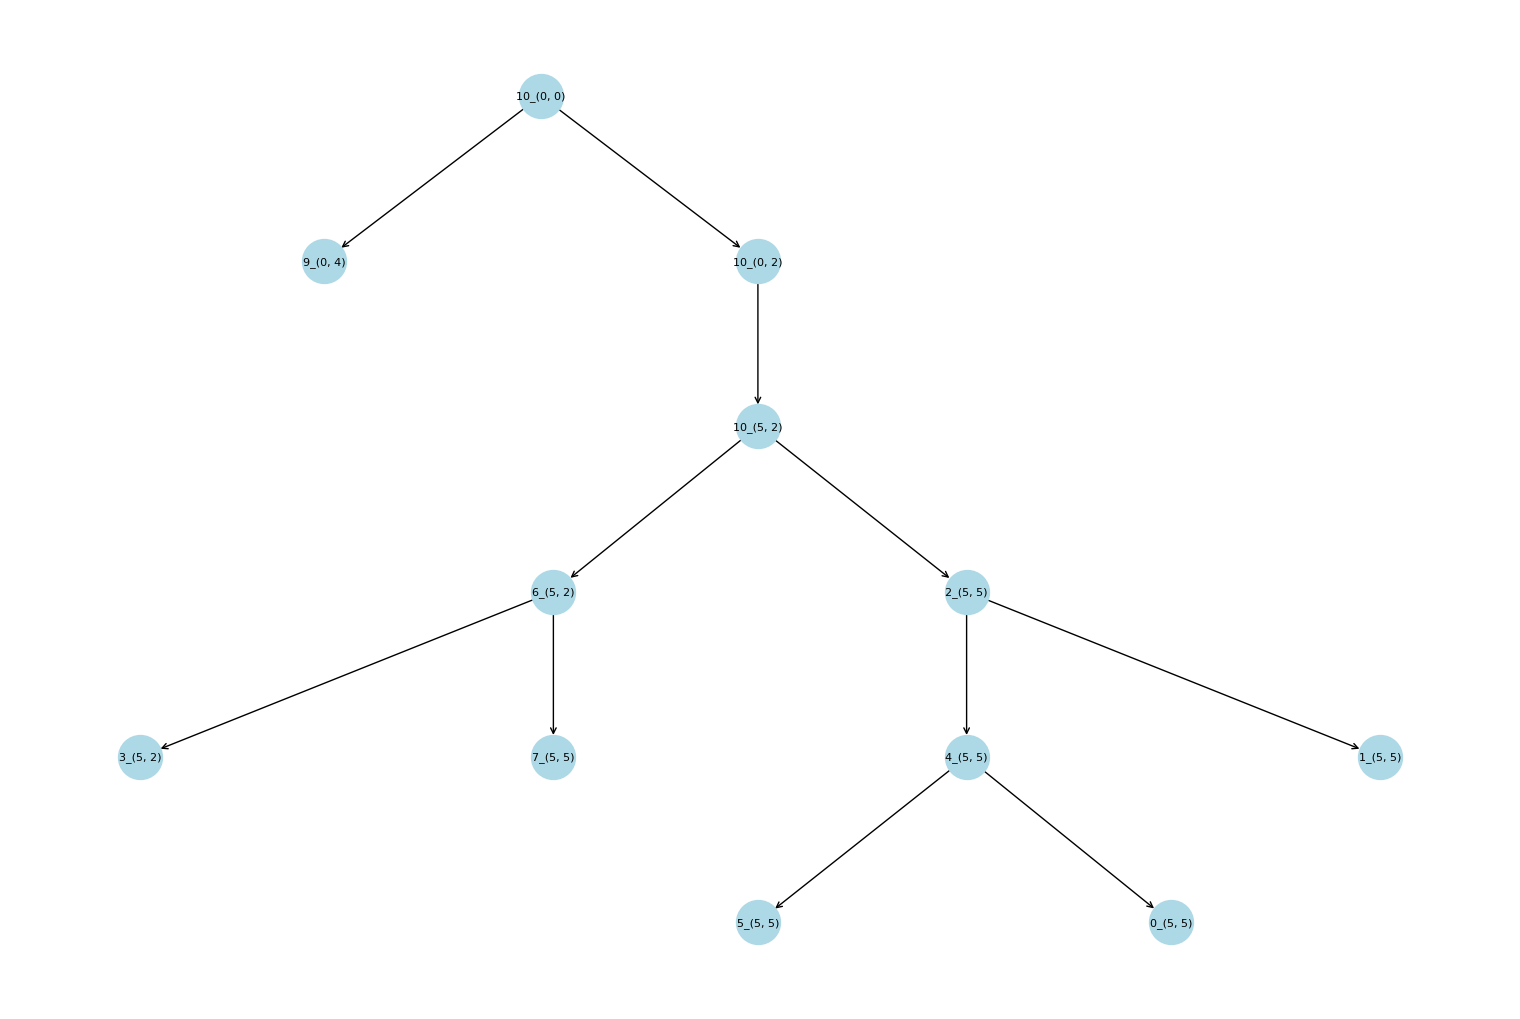

In [1373]:
plt.figure(figsize=(15,10))

pos = graphviz_layout(tree_m,prog='dot',args=f"-Grankdir-TB")
nx.draw(tree_m,pos,with_labels=True,node_size=1000,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,node_color='lightblue')

plt.tight_layout()
plt.show()

In [1374]:
# plt.figure(figsize=(15,10))

# pos = graphviz_layout(tree_cp,prog='dot',args=f"-Grankdir-TB")
# nx.draw(tree_cp,pos,with_labels=True,node_size=1000,font_size=8,arrows=True,arrowstyle="->",arrowsize=10,node_color='lightblue')

# plt.tight_layout()
# plt.show()

In [1375]:
root_and_leaves = [x for x in contracted_tree.nodes() if (contracted_tree.out_degree(x)==0 or x==root)]

In [1376]:
isotype_labels = {
    node: contracted_states[node]['isotype']
    for node in root_and_leaves
}

In [1377]:
P = isotype.P
# cost = -np.log(P + 1e-9)
cost = -np.log(P)

In [1378]:
cost

array([[ 1.28125939,  1.84950612,  3.62908153,  1.21583102,  2.40366756,
         1.88645802],
       [        inf,  1.87480456,  2.01645148,  1.21729799,  1.88763047,
         1.32415047],
       [        inf,         inf,  1.54480897,  0.9394742 ,  2.7921535 ,
         1.09504364],
       [        inf,         inf,         inf,  0.80803175,  2.08520522,
         0.84400759],
       [        inf,         inf,         inf,         inf,  4.26171708,
         0.0141984 ],
       [        inf,         inf,         inf,         inf,         inf,
        -0.        ]])

In [1379]:
base_tree = BaseTree(contracted_tree, root=root, id=0, name="contracted_test")

cg = ConstructGraph(cost, isotype_labels, root_identifier=root)
fg = cg.build(base_tree)

In [1380]:
mptr1 = MPTR_original(
    fg.G,
    base_tree.T,
    fg.find_terminals(),
    fg.iso_weights,
    fg.tree_to_graph,
    root=root,
)
score1, tree1 = mptr1.run()
print(f"Original MPTR objective = {score1:.4f}")

mptr2 = MPTR_DAG(
    fg.G,
    base_tree.T,
    fg.find_terminals(),
    fg.iso_weights,
    fg.tree_to_graph,
    root=root,
)
score2, tree2 = mptr2.run()
print(f"New MPTR_DAG objective = {score2:.4f}")

Original MPTR objective = 5.0542
New MPTR_DAG objective = 5.0542


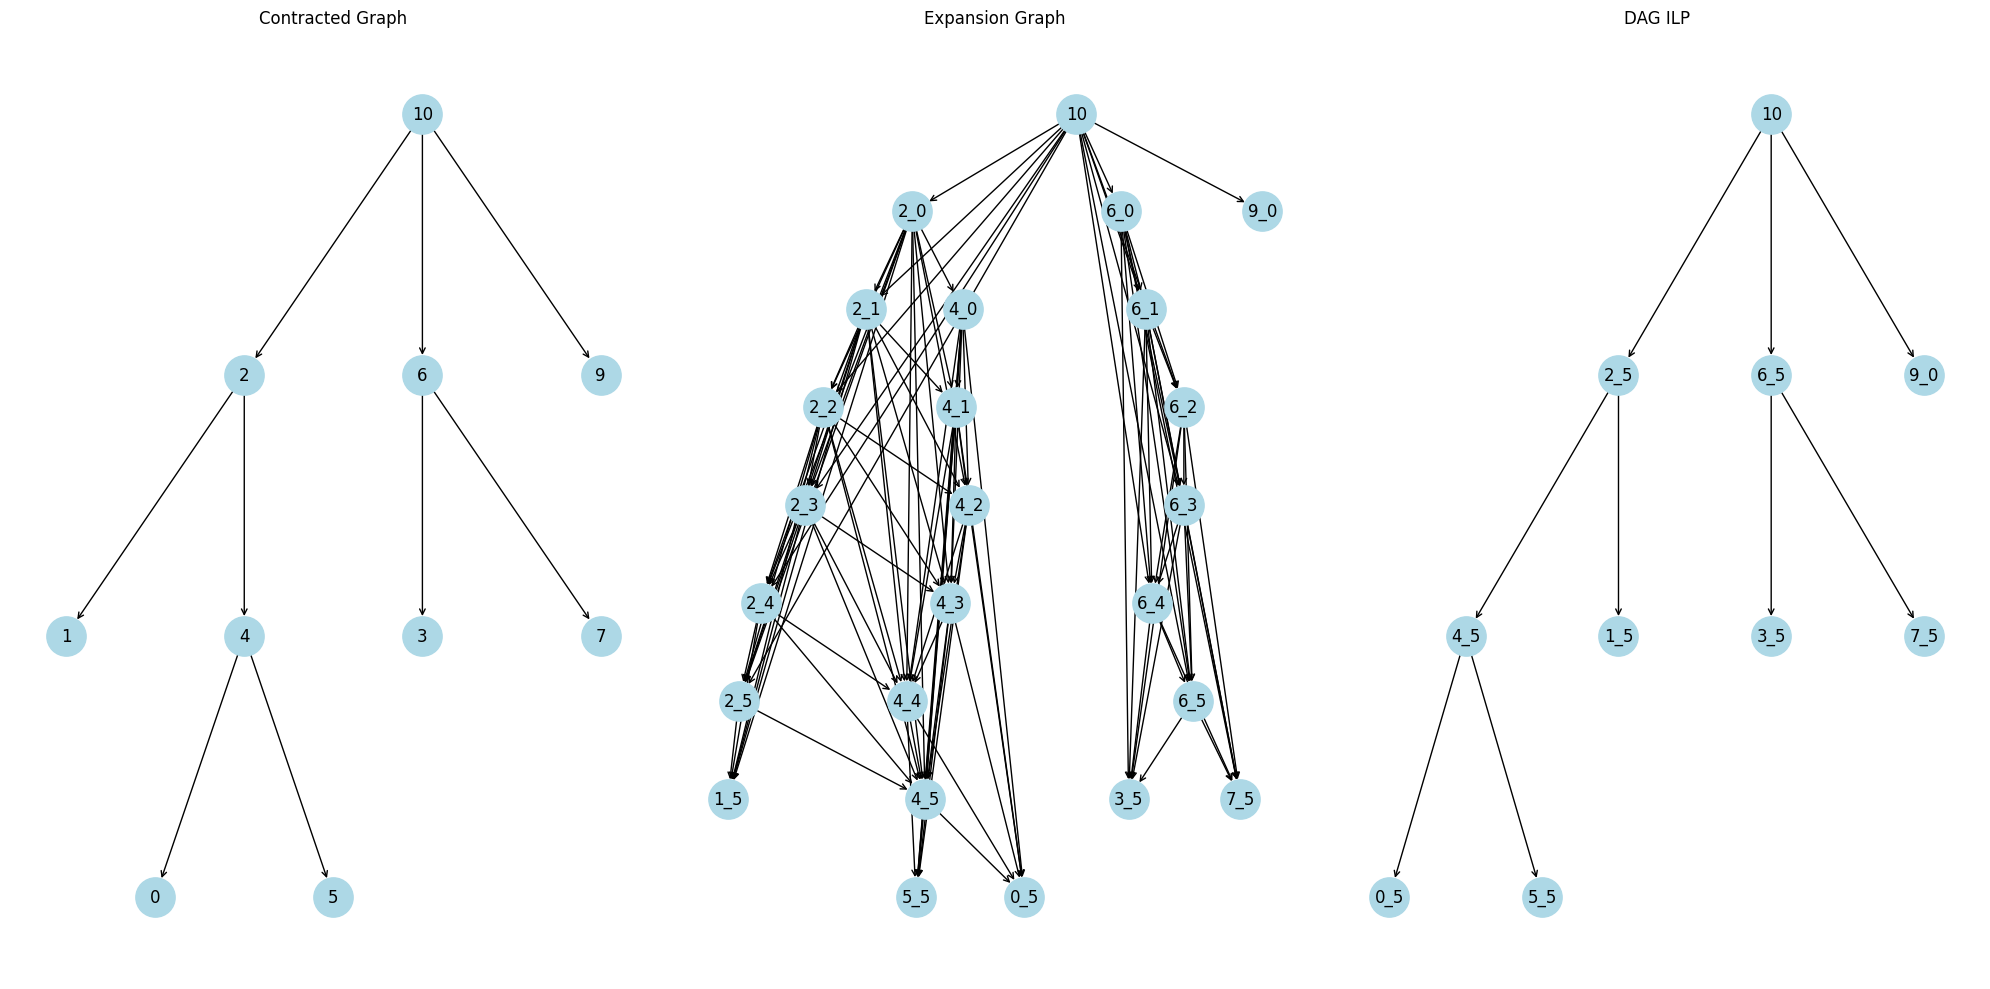

In [1381]:
def draw_tree(tree,i):
    pos = graphviz_layout(tree,prog='dot',args=f"-Grankdir-TB")
    nx.draw(tree,pos,with_labels=True,node_size=800,font_size=12,arrows=True,arrowstyle="->",arrowsize=10,ax=axes[i],node_color='lightblue')


fig,axes = plt.subplots(1, 3, figsize=(20,10))

draw_tree(contracted_tree,0)
axes[0].set_title("Contracted Graph")

draw_tree(fg.G,1)
axes[1].set_title("Expansion Graph")

# draw_tree(tree,1)
# axes[1].set_title("Original Graph")

draw_tree(tree2,2)
axes[2].set_title("DAG ILP")

plt.tight_layout()
plt.show()